In [1]:
import os
import glob
import time
import warnings
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from tqdm import tqdm

In [2]:
# ==========================================
# 1. UWF ELLIPTICAL MASKING & PREPROCESSING
# ==========================================
import cv2
import numpy as np
from PIL import Image

def apply_uwf_mask(pil_img, tightness=0.98):
    """
    Applies an elliptical mask tailored for UWF images (Optos, etc.) 
    to remove eyelid and eyelash artifacts on the far periphery.
    """
    img = np.array(pil_img)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    
    # Thresholding to find the wide-field boundary
    _, thresh = cv2.threshold(gray, 15, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if not contours:
        return pil_img

    # Find the largest contour (the retina)
    largest_contour = max(contours, key=cv2.contourArea)
    
    # Fit an ellipse to handle UWF's non-circular geometry
    if len(largest_contour) >= 5:
        ellipse = cv2.fitEllipse(largest_contour)
        
        # Scale down ellipse by 'tightness' to crop out boundary artifacts
        scaled_ellipse = (ellipse[0], (ellipse[1][0]*tightness, ellipse[1][1]*tightness), ellipse[2])
        mask = np.zeros_like(gray)
        cv2.ellipse(mask, scaled_ellipse, 255, -1)
        
        # Apply mask
        clean_img = cv2.bitwise_and(img, img, mask=mask)
        return Image.fromarray(clean_img)
    
    return pil_img

In [3]:
# ==========================================
# 2. UWF-OPTIMIZED LOSS FUNCTIONS
# ==========================================
import torch
import torch.nn as nn

class FocalLossMultiClass(nn.Module):
    """Focal Loss for Severity Grading (Head B)"""
    def __init__(self, alpha=1.0, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(reduction='none')

    def forward(self, inputs, targets):
        ce_loss = self.ce(inputs, targets)
        pt = torch.exp(-ce_loss)
        return (self.alpha * (1 - pt) ** self.gamma * ce_loss).mean()

class FocalLossMultiLabel(nn.Module):
    """Focal Loss for highly imbalanced peripheral lesions (Head A)"""
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.bce = nn.BCEWithLogitsLoss(reduction='none')

    def forward(self, inputs, targets):
        bce_loss = self.bce(inputs, targets)
        pt = torch.exp(-bce_loss) 
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss
        return focal_loss.mean()

In [4]:
# ==========================================
# 3. UWF MULTI-SCALE DRNET (LOCAL WEIGHTS)
# ==========================================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models

class SpatialAttention(nn.Module):
    """Helps the network focus on tiny peripheral lesions across 200-degrees"""
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x_out = self.conv(torch.cat([avg_out, max_out], dim=1))
        return x * self.sigmoid(x_out)

class UWF_MultiScaleDRNet(nn.Module):
    def __init__(self):
        super().__init__()
        
        # 1. Initialize ResNet WITHOUT downloading weights
        resnet = models.resnet50(weights=None)
        
        # 2. Load your manually downloaded weights
        local_weights = torch.load('resnet50-0676ba61.pth', weights_only=True)
        resnet.load_state_dict(local_weights)
        
        self.stem = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool)
        self.layer1 = resnet.layer1  # 256
        self.layer2 = resnet.layer2  # 512
        self.layer3 = resnet.layer3  # 1024
        self.layer4 = resnet.layer4  # 2048
        
        # 3. FPN 1x1 Convs to equalize channels to 512 (Restored!)
        self.lat_l4 = nn.Conv2d(2048, 512, kernel_size=1)
        self.lat_l3 = nn.Conv2d(1024, 512, kernel_size=1)
        self.lat_l2 = nn.Conv2d(512, 512, kernel_size=1)
        self.lat_l1 = nn.Conv2d(256, 512, kernel_size=1)
        
        self.attention = SpatialAttention()
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        self.head_a_lesion = nn.Linear(512, 7)  
        self.head_b_grade = nn.Linear(512, 5)   

    def forward(self, x):
        x = self.stem(x)
        
        # Bottom-up
        l1 = self.layer1(x)
        l2 = self.layer2(l1)
        l3 = self.layer3(l2)
        l4 = self.layer4(l3)
        
        # Top-down FPN Fusion
        p4 = self.lat_l4(l4)
        p3 = self.lat_l3(l3) + F.interpolate(p4, size=l3.shape[-2:], mode='bilinear', align_corners=False)
        p2 = self.lat_l2(l2) + F.interpolate(p3, size=l2.shape[-2:], mode='bilinear', align_corners=False)
        p1 = self.lat_l1(l1) + F.interpolate(p2, size=l1.shape[-2:], mode='bilinear', align_corners=False)
        
        # Apply Spatial Attention on the richest high-res fused map (p1)
        attended_features = self.attention(p1)
        
        # Pool and classify
        pooled = self.global_pool(attended_features).flatten(1)
        lesion_logits = self.head_a_lesion(pooled)
        grade_logits = self.head_b_grade(pooled)
        
        return grade_logits, lesion_logits

In [5]:
# ==========================================
# 3. DATASET MANAGEMENT
# ==========================================
from torch.utils.data import Dataset
import os
import pandas as pd
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split

class MMRDRDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = resolve_image_path(self.img_dir, str(row['image']))
        if img_path is None or not os.path.exists(img_path):
            img_path = os.path.join(self.img_dir, str(row['image']))
            
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception:
            # Fallback canvas ensures loader never crashes
            image = Image.new('RGB', (1024, 1024), (0, 0, 0))
        
        # ---> UPDATED FOR UWF <---
        image = apply_uwf_mask(image) 
        
        if self.transform:
            image = self.transform(image)
            
        grade_label = int(row['grade'])
        
        # Robust string parser for '[1, 0, 0, 1...]' formats
        lesion_str = str(row['lesion']).strip()
        if lesion_str.startswith('[') and lesion_str.endswith(']'):
            lesion_str = lesion_str[1:-1]
        
        try:
            lesion_labels = np.array([float(x.strip()) for x in lesion_str.split(',') if x.strip() != ''], dtype=np.float32)
            if len(lesion_labels) != 7:
                raise ValueError
        except ValueError:
            lesion_labels = np.zeros(7, dtype=np.float32)
                
        return image, grade_label, lesion_labels

def resolve_data_dir(base_path):
    if os.path.isabs(base_path):
        return base_path
    return os.path.normpath(os.path.join(os.path.dirname(__file__), base_path))

def execute_mmrdr_split(base_path, modality):
    data_dir = resolve_data_dir(base_path)
    modality_label = 'FP' if modality.lower() == 'cfp' else modality.upper()
    file_path = os.path.join(data_dir, f'MMRDR-{modality.upper()}', f'{modality_label}.csv')
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Critical Error: Metadata sheet not found at {file_path}")
        
    df = pd.read_csv(file_path)
    train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
    return train_df, test_df

def resolve_image_path(img_root, image_field):
    image_field = str(image_field).strip().replace("\\", "/")
    image_field = image_field.lstrip("./")

    candidates = [
        os.path.join(img_root, image_field),
        os.path.join(img_root, os.path.basename(image_field)),
        os.path.join(img_root, "img", os.path.basename(image_field)),
        os.path.join(img_root, "img", image_field),
    ]

    seen = set()
    unique_candidates = []
    for c in candidates:
        c = os.path.normpath(c)
        if c not in seen:
            seen.add(c)
            unique_candidates.append(c)

    for path in unique_candidates:
        if os.path.exists(path):
            return path
    return None

In [6]:
import os

folder_path = "MMRDR/MMRDR-UWF/img" # Add '/img' if they are in a subfolder
valid_exts = ('.png', '.jpg', '.jpeg', '.tif', '.tiff')

count = sum(1 for f in os.listdir(folder_path) if f.lower().endswith(valid_exts))
print(f"Total images ready for training: {count}")

Total images ready for training: 10404


Visualizing a UWF batch...


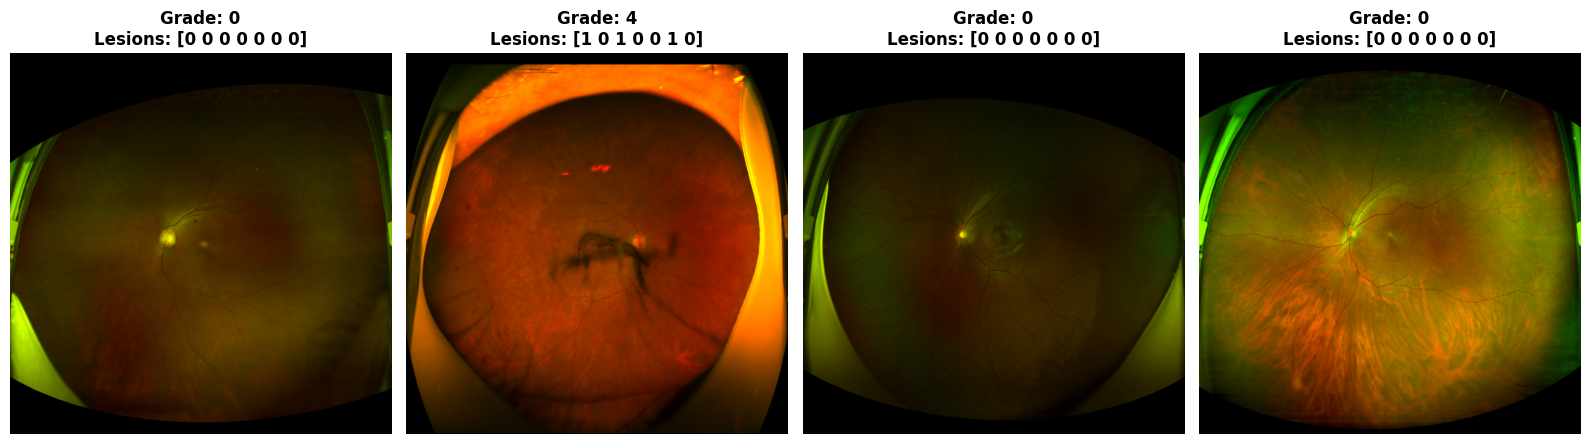

In [7]:
# ==========================================
# 3.5. DATASET VISUALIZATION CHECK
# ==========================================
import os
import torch
import matplotlib.pyplot as plt
import numpy as np
from torchvision import transforms
from torch.utils.data import DataLoader

# 1. Define the visualization function
def visualize_batch(dataloader, num_images=4):
    """Fetches a batch from the dataloader and plots it with labels."""
    images, grade_labels, lesion_labels = next(iter(dataloader))
    
    # Restrict to num_images
    images = images[:num_images]
    grade_labels = grade_labels[:num_images]
    lesion_labels = lesion_labels[:num_images]
    
    # ImageNet Denormalization for viewing
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    
    fig, axes = plt.subplots(1, num_images, figsize=(16, 5))
    if num_images == 1: axes = [axes]
        
    for i in range(num_images):
        # Denormalize and convert to numpy HWC
        img = images[i] * std + mean
        img = torch.clamp(img, 0, 1).permute(1, 2, 0).numpy()
        
        grade = grade_labels[i].item()
        lesions = lesion_labels[i].int().numpy()
        
        axes[i].imshow(img)
        axes[i].set_title(f"Grade: {grade}\nLesions: {lesions}", fontsize=12, fontweight='bold')
        axes[i].axis('off')
        
    plt.tight_layout()
    plt.show()

# 2. Setup paths and load data
data_dir = os.path.abspath("MMRDR")
modality = "uwf"
img_size = 1024
img_root = os.path.join(data_dir, f"MMRDR-{modality.upper()}")

# (Make sure the cell with execute_mmrdr_split is run before this!)
train_df, _ = execute_mmrdr_split(data_dir, modality)

viz_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

viz_loader = DataLoader(
    MMRDRDataset(train_df, img_root, viz_transform),
    batch_size=4, shuffle=True
)

# 3. Plot it!
print("Visualizing a UWF batch...")
visualize_batch(viz_loader, num_images=4)

In [26]:
# ==========================================
# 4. TRAINING ENGINE PIPELINE (UWF UPDATED)
# ==========================================
def main():
    data_dir = os.path.abspath("MMRDR")
    modality = "uwf"           # Changed to UWF

    # --- HYPERPARAMETERS ---
    batch_size = 4             # Adjusted for 1024x1024
    accumulation_steps = 6     # Effective batch = 24
    num_workers = 4            
    img_size = 1024            # Bumped to 1024x1024
    epochs = 50                
    patience = 8
    lr = 3e-4                  
    output_model = 'best_uwf_multiscale_resnet.pth'
    # -----------------------

    torch.backends.cudnn.benchmark = True
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    use_amp = device.type == "cuda"
    print(f"Execution Target Device: {device} | AMP Enabled: {use_amp}")

    train_df, test_df = execute_mmrdr_split(data_dir, modality)
    img_root = os.path.join(data_dir, f"MMRDR-{modality.upper()}")

    # 1024x1024 Augmentations
    train_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    val_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    train_loader = DataLoader(
        MMRDRDataset(train_df, img_root, train_transform),
        batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True
    )

    test_loader = DataLoader(
        MMRDRDataset(test_df, img_root, val_transform),
        batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True
    )

    # Instantiate NEW model
    model = UWF_MultiScaleDRNet().to(device)

    # NEW UWF-Optimized Losses
    criterion_grade = FocalLossMultiClass(alpha=1.0, gamma=2.0)
    criterion_lesion = FocalLossMultiLabel(alpha=0.25, gamma=2.0)

    # --- THE REST REMAINS EXACTLY THE SAME ---
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scaler = torch.cuda.amp.GradScaler() if use_amp else None

    best_grade_acc = 0.0
    epochs_without_improve = 0

    print(f"\nStarting UWF Multi-Scale training for {epochs} epochs at {img_size}x{img_size} resolution...")
    for epoch in range(epochs):
        epoch_start = time.time()
        model.train()
        running_loss = 0.0
        optimizer.zero_grad()

        train_bar = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch + 1}/{epochs} [train]", ncols=100)

        for i, (images, grade_labels, lesion_labels) in train_bar:
            images = images.to(device, non_blocking=True)
            grade_labels = grade_labels.to(device, non_blocking=True)
            lesion_labels = lesion_labels.to(device, non_blocking=True).float()

            with torch.amp.autocast('cuda', enabled=use_amp):
                grade_logits, lesion_logits = model(images)
                
                loss_grade = criterion_grade(grade_logits, grade_labels)
                loss_lesion = criterion_lesion(lesion_logits, lesion_labels)
                
                # Combined Loss
                total_loss = loss_grade + (1.5 * loss_lesion)
                loss_scaled = total_loss / accumulation_steps

            if use_amp and scaler is not None:
                scaler.scale(loss_scaled).backward()
                if (i + 1) % accumulation_steps == 0 or (i + 1) == len(train_loader):
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    scaler.step(optimizer)
                    scaler.update()
                    optimizer.zero_grad()
            else:
                loss_scaled.backward()
                if (i + 1) % accumulation_steps == 0 or (i + 1) == len(train_loader):
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    optimizer.step()
                    optimizer.zero_grad()

            running_loss += total_loss.item()
            train_bar.set_postfix(loss=f"{total_loss.item():.4f}")

        # Validation Phase
        model.eval()
        grade_correct, grade_total = 0, 0
        lesion_correct, lesion_total = 0, 0

        val_bar = tqdm(test_loader, total=len(test_loader), desc=f"Epoch {epoch + 1}/{epochs} [val]", ncols=100)

        with torch.no_grad():
            for images, grade_labels, lesion_labels in val_bar:
                images = images.to(device, non_blocking=True)
                grade_labels = grade_labels.to(device, non_blocking=True)
                lesion_labels = lesion_labels.to(device, non_blocking=True).float()

                with torch.amp.autocast('cuda', enabled=use_amp):
                    grade_logits, lesion_logits = model(images)
                    
                    # Grade Eval
                    _, grade_preds = torch.max(grade_logits, 1)
                    grade_total += grade_labels.size(0)
                    grade_correct += (grade_preds == grade_labels).sum().item()
                    
                    # Lesion Eval
                    lesion_preds = (torch.sigmoid(lesion_logits) > 0.5).float()
                    lesion_total += lesion_labels.numel()
                    lesion_correct += (lesion_preds == lesion_labels).sum().item()

                val_bar.set_postfix(
                    Grade_Acc=f"{grade_correct/grade_total:.4f}", 
                    Lesion_Acc=f"{lesion_correct/lesion_total:.4f}"
                )

        epoch_grade_acc = grade_correct / grade_total
        epoch_lesion_acc = lesion_correct / lesion_total
        avg_loss = running_loss / max(len(train_loader), 1)
        epoch_elapsed = time.time() - epoch_start

        print(
            f"Epoch [{epoch + 1}/{epochs}] | Loss: {avg_loss:.4f} | "
            f"Grade Acc: {epoch_grade_acc:.4f} | Lesion Acc: {epoch_lesion_acc:.4f} | Time: {epoch_elapsed:.1f}s"
        )

        # Autosave
        if epoch_grade_acc > best_grade_acc:
            best_grade_acc = epoch_grade_acc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'grade_acc': best_grade_acc,
            }, output_model)
            epochs_without_improve = 0
            print(f"★ Saved Best Model: {output_model} | Grade Acc: {best_grade_acc:.4f} ★")
        else:
            epochs_without_improve += 1

        if epochs_without_improve >= patience:
            print(f"Early stopping at epoch {epoch + 1}. Best Validation Grade Accuracy: {best_grade_acc:.4f}")
            break


main()

Execution Target Device: cuda | AMP Enabled: True

Starting UWF Multi-Scale training for 50 epochs at 1024x1024 resolution...


Epoch 1/50 [val]: 100%|██████| 521/521 [01:41<00:00,  5.13it/s, Grade_Acc=0.5637, Lesion_Acc=0.8624]


Epoch [1/50] | Loss: 0.7198 | Grade Acc: 0.5637 | Lesion Acc: 0.8624 | Time: 795.6s
★ Saved Best Model: best_uwf_multiscale_resnet.pth | Grade Acc: 0.5637 ★


Epoch 2/50 [val]: 100%|██████| 521/521 [01:29<00:00,  5.81it/s, Grade_Acc=0.6838, Lesion_Acc=0.8925]


Epoch [2/50] | Loss: 0.4853 | Grade Acc: 0.6838 | Lesion Acc: 0.8925 | Time: 776.6s
★ Saved Best Model: best_uwf_multiscale_resnet.pth | Grade Acc: 0.6838 ★


...

Epoch [26/50] | Loss: 0.2878 | Grade Acc: 0.7074 | Lesion Acc: 0.9012 | Time: 771.7s



Epoch 27/50 [val]: 100%|█████| 521/521 [01:28<00:00,  5.88it/s, Grade_Acc=0.7059, Lesion_Acc=0.9008]

Epoch [27/50] | Loss: 0.2818 | Grade Acc: 0.7059 | Lesion Acc: 0.9008 | Time: 769.9s



Epoch 28/50 [val]: 100%|█████| 521/521 [01:26<00:00,  5.99it/s, Grade_Acc=0.7338, Lesion_Acc=0.9026]

Epoch [28/50] | Loss: 0.2807 | Grade Acc: 0.7338 | Lesion Acc: 0.9026 | Time: 768.1s
Early stopping at epoch 28. Best Validation Grade Accuracy: 0.7448


Loading Model Weights...


/home/user3/miniforge3/envs/jupyterenv/lib/python3.11/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


Generating AI X-Ray Heatmaps (Memory Safe Mode)...


OutOfMemoryError: CUDA out of memory. Tried to allocate 64.00 MiB. GPU 0 has a total capacty of 15.57 GiB of which 16.19 MiB is free. Including non-PyTorch memory, this process has 15.53 GiB memory in use. Of the allocated memory 15.31 GiB is allocated by PyTorch, and 78.28 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF

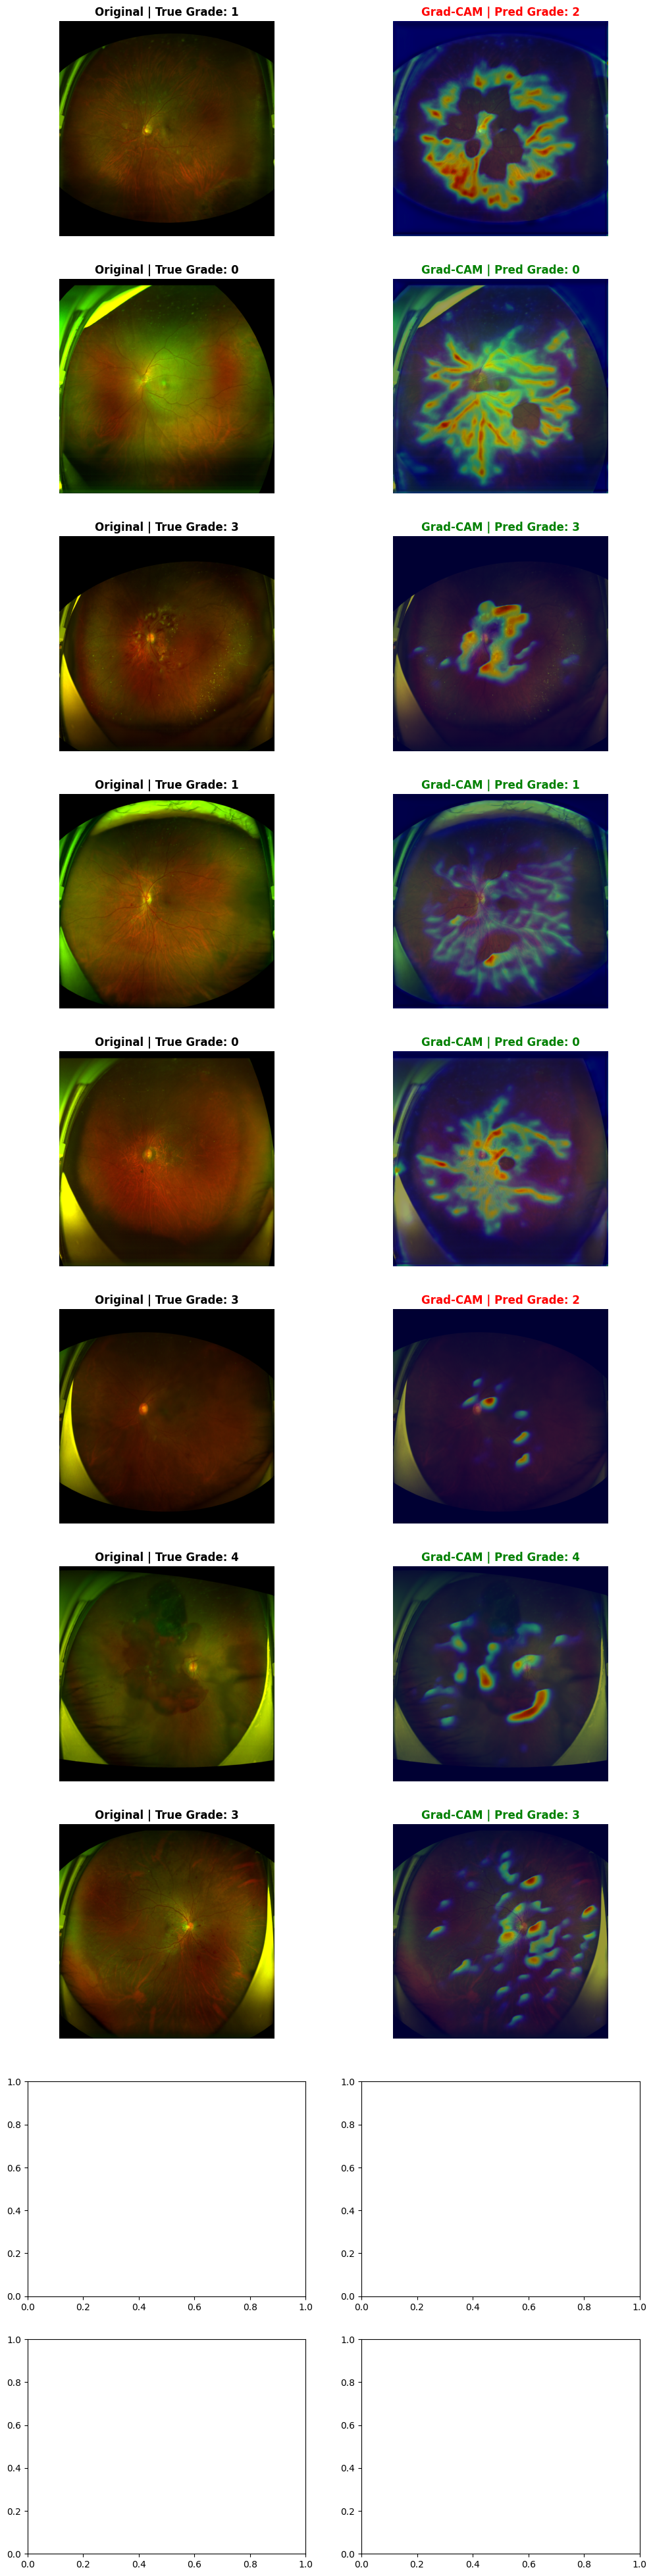

In [8]:
# ==========================================
# 5. GRAD-CAM: VISUALIZING THE AI'S BRAIN (True Memory-Safe)
# ==========================================
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torchvision import transforms
from torch.utils.data import DataLoader

class UWF_GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None
        
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate_cam(self, input_tensor, class_idx, head='grade'):
        self.model.zero_grad()
        grade_logits, lesion_logits = self.model(input_tensor)
        
        target = grade_logits[0, class_idx] if head == 'grade' else lesion_logits[0, class_idx]
        target.backward(retain_graph=True)
        
        weights = torch.mean(self.gradients, dim=[2, 3], keepdim=True)
        cam = torch.sum(weights * self.activations, dim=1).squeeze()
        cam = F.relu(cam) 
        
        cam -= cam.min()
        cam /= (cam.max() + 1e-8)
        return cam.cpu().detach().numpy(), grade_logits, lesion_logits

def verify_with_heatmaps_safe(model, dataloader, device, num_images=10):
    model.eval()
    cam_extractor = UWF_GradCAM(model, model.attention) 
    
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1).to('cpu')
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1).to('cpu')
    
    fig, axes = plt.subplots(num_images, 2, figsize=(12, 5 * num_images))
    if num_images == 1: axes = [axes]
        
    iterator = iter(dataloader)
    
    for i in range(num_images):
        try:
            images, grade_labels, _ = next(iterator)
        except StopIteration:
            break
            
        # 1. Grab strictly ONE image
        img_tensor = images[0].unsqueeze(0).to(device)
        true_grade = grade_labels[0].item()
        
        # 2. Run Forward & Backward for CAM
        with torch.enable_grad():
            cam, grade_logits, _ = cam_extractor.generate_cam(img_tensor, true_grade, head='grade')
            pred_grade = torch.argmax(grade_logits, dim=1).item()
        
        # 3. IMMEDIATELY move data to CPU & wipe GPU cache
        cam_resized = cv2.resize(cam, (img_tensor.shape[3], img_tensor.shape[2]))
        img_cpu = img_tensor.squeeze(0).cpu() 
        del img_tensor, cam, grade_logits
        torch.cuda.empty_cache()
        
        # 4. Do visual processing on CPU RAM
        heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
        
        orig_img = (img_cpu * std + mean).clamp(0, 1).numpy().transpose(1, 2, 0)
        overlay = np.clip(heatmap * 0.4 + orig_img * 0.6, 0, 1)
        
        # 5. Plot
        axes[i, 0].imshow(orig_img)
        axes[i, 0].set_title(f"Original | True Grade: {true_grade}", fontweight='bold')
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(overlay)
        title_color = 'green' if true_grade == pred_grade else 'red'
        axes[i, 1].set_title(f"Grad-CAM | Pred Grade: {pred_grade}", color=title_color, fontweight='bold')
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()

# ==========================================
# EXECUTION 
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

data_dir = os.path.abspath("MMRDR")
modality = "uwf"
img_size = 1024
img_root = os.path.join(data_dir, f"MMRDR-{modality.upper()}")

_, test_df = execute_mmrdr_split(data_dir, modality)

val_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# STRICTLY Batch Size 1
local_test_loader = DataLoader(
    MMRDRDataset(test_df, img_root, val_transform),
    batch_size=1, shuffle=True 
)

print("Loading Model Weights...")
model_path = 'best_uwf_multiscale_resnet.pth' 
loaded_model = UWF_MultiScaleDRNet().to(device)
loaded_model.load_state_dict(torch.load(model_path, map_location=device)['model_state_dict'])

print("Generating AI X-Ray Heatmaps (Memory Safe Mode)...")
verify_with_heatmaps_safe(loaded_model, local_test_loader, device, num_images=10)